In [1]:
# load libraies

%run py_libraries.py

/Users/4476224/.local/lib/python3.8/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.6.0 and strictly below 2.9.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


In [2]:
# loading utility files

from utility.sv_fig import savefig
# from utility.mi_score import MI_score



In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_row', None)

# load data
X_train = pd.read_csv('data/norm_X_train_PCa_Ca.csv')
X_test = pd.read_csv('data/norm_X_test_PCa_Ca.csv')
y_train = pd.read_csv('data/y_train_PCa_Ca.csv')
y_test = pd.read_csv('data/y_test_PCa_Ca.csv')


print(X_train.shape)

(109, 37)


In [4]:
Xy_PCa_Ca = pd.concat([X_train, y_train], axis=1)

In [5]:
# file A
file_A = Xy_PCa_Ca.copy()

In [6]:
#file B

file_B = pd.read_csv('output_PCa_Ca.csv')

In [7]:
# compare imputation for Ca in file_A


file_A2 = file_A[file_A["CACHEXSTAGE0VIG"] == 1]

In [8]:
# compare imputation for Ca in file_B


file_B2 = file_B[file_B["CACHEXSTAGE0VIG"] == 1]

In [9]:


# mask of missing values in A
mask = file_A.isna()

# values that were imputed
imputed_values = file_B[mask]

In [10]:
# print(file_B.isna().sum())

In [11]:
comparison = []

for col in file_A.columns:
    if file_A[col].isna().sum() > 0:
        original = file_A[col].dropna()
        imputed = file_B[col][mask[col]]
        num_miss = len(imputed)
        print(imputed)
        
        comparison.append({
            'column': col,
            'Training_cohort_mean': original.mean(),
            'Imputed_data_mean': imputed.mean(),
            'Training_cohort_std': original.std(),
            'Imputed_data_std': imputed.std(),
            'Num_of_imputed_data': num_miss
        })

pd.DataFrame(comparison)

60    0.253918
Name: IL.10, dtype: float64
6     0.623870
7     0.622581
20    0.568215
76    0.537281
Name: MIP.1a, dtype: float64
68    0.795438
Name: C.peptide, dtype: float64
15    0.285822
25    0.365800
43    0.212984
44    0.200965
69    0.356447
Name: IL.22, dtype: float64
44    0.701684
55    0.709499
68    0.688465
Name: Insulin, dtype: float64
2     0.740362
44    0.770307
62    0.791993
Name: Leptin, dtype: float64
5      0.547048
7      0.516095
11     0.489218
43     0.357914
47     0.494704
93     0.479033
104    0.417390
Name: MIP.3a, dtype: float64
44    0.934083
63    0.977028
Name: MMP.2, dtype: float64
2      0.631576
12     0.542675
40     0.883794
42     0.619437
48     0.668064
57     0.632157
64     0.693549
74     0.703099
95     0.763202
105    0.626124
Name: TGF.B2, dtype: float64
2    0.523157
Name: PPAR.y, dtype: float64
0      0.626646
19     0.664890
41     0.699763
54     0.589499
57     0.671793
60     0.737457
94     0.920281
101    0.715087
Name: HIF.

,column,Training_cohort_mean,Imputed_data_mean,Training_cohort_std,Imputed_data_std,Num_of_imputed_data
0,IL.10,0.378101,0.253918,0.212407,NaN,1
1,MIP.1a,0.553464,0.587987,0.093822,0.042608,4
2,C.peptide,0.860125,0.795438,0.063338,NaN,1
3,IL.22,0.236331,0.284404,0.165317,0.077267,5
4,Insulin,0.728833,0.699883,0.150117,0.010632,3
5,Leptin,0.758395,0.767554,0.093716,0.025926,3
6,MIP.3a,0.483343,0.471629,0.124698,0.063816,7
7,MMP.2,0.918196,0.955556,0.050182,0.030367,2
8,TGF.B2,0.729569,0.676368,0.133289,0.093835,10
9,PPAR.y,0.402075,0.523157,0.220233,NaN,1


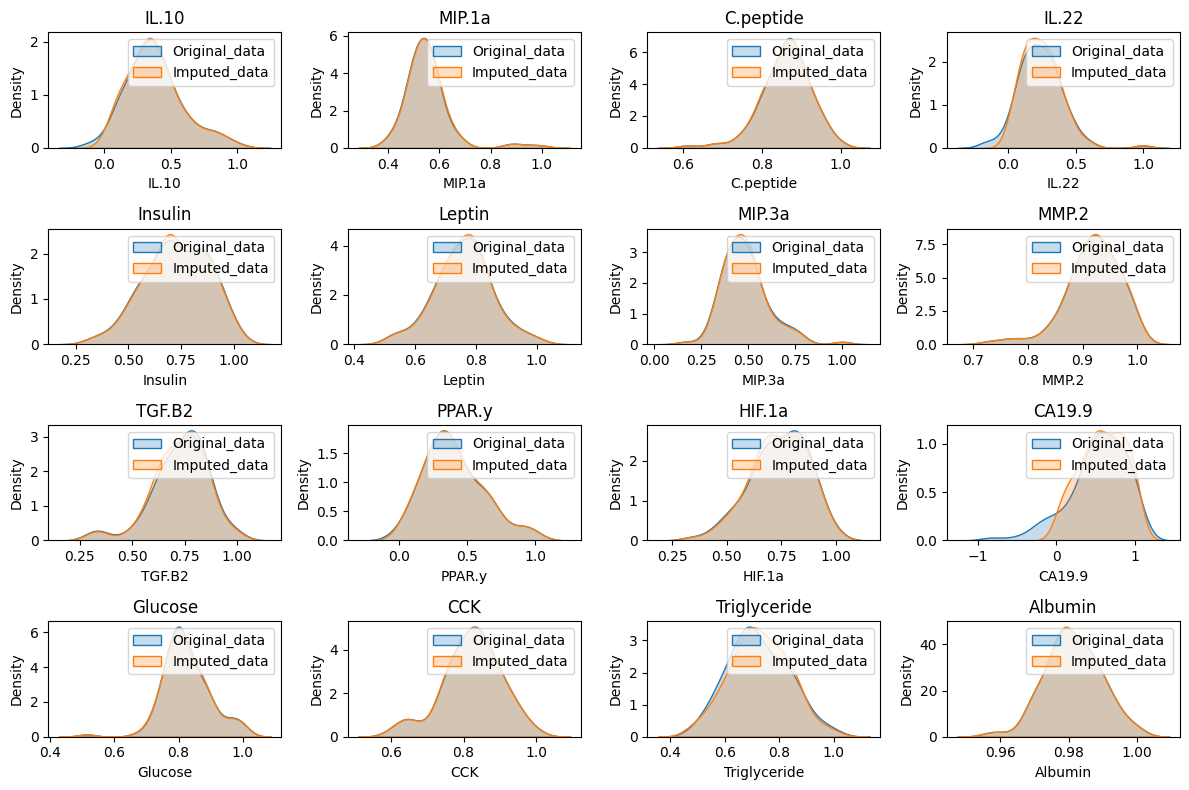

In [13]:
# comparison original vs imputed
import math

cols = ['IL.10', 'MIP.1a', 'C.peptide', 'IL.22', 'Insulin', 'Leptin', 'MIP.3a', 'MMP.2', 'TGF.B2', 'PPAR.y', 'HIF.1a', 'CA19.9', 'Glucose', 'CCK', 'Triglyceride','Albumin' ]

n_cols = 4  
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(file_A[col], label='Original_data', fill=True, ax=axes[i])
    sns.kdeplot(file_B[col], label='Imputed_data', fill=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend()

# remove unused subplots (if any)
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
# plt.show()
savefig('./figs/PCa_Ca_den',dpi=600,quality=100)